# Quicksort

**Domain:** `data-structures-algorithms`

Imagine you're a librarian with a cart of returned books in a random jumble,
and you need to shelve them in call-number order. You don't have a second
cart to lay every book out on — you only have the one cart. A natural trick:
**grab one book at random, call it your "marker,"** then walk the cart once,
tossing every book that comes before the marker to the left end and
everything that comes after to the right end. When you're done, the marker
is exactly where it belongs — every book to its left really does belong to
its left, and everything to its right really does belong to its right.

You still have two smaller messy piles. So you do the exact same trick to
each pile. And each of *those* piles splits into two smaller piles. Keep
going, and eventually every pile has zero or one book in it — which is
already sorted, trivially — and the whole cart is in order.

That's **quicksort**, in full. No formulas required yet:

- **Pick a pivot** (the marker book).
- **Partition**: rearrange so everything smaller than the pivot ends up to
  its left, everything larger ends up to its right, and the pivot lands in
  its final position.
- **Recurse** on the left part and the right part.

By the end of this tutorial you'll be able to: explain *why* this sorts
correctly, derive its average- and worst-case running time, watch it sort
real numbers step by step, and run a real, compiled C++ implementation that
reports its own comparison/swap counts and wall-clock time.

## The idea, intuitively

**The one operation that matters is *partitioning*.** Everything else is
"do it again, but on a smaller list."

Let's make this concrete with 7 small numbers and watch one partition step
happen, using the *last* element as the pivot (a common, simple choice):

```
[7, 2, 9, 4, 1, 8, 3]     pivot = 3 (last element)
```

Walk left to right. Keep a boundary `i` marking "everything at or before
here, among what we've scanned, is <= pivot." Every time we see a value
`<= 3`, we swap it just past the boundary and advance the boundary.

- `7`: bigger than 3, skip.
- `2`: `<= 3`, swap into boundary slot &rarr; `[2, 7, 9, 4, 1, 8, 3]`, boundary advances.
- `9`: bigger, skip.
- `4`: bigger, skip.
- `1`: `<= 3`, swap into boundary slot &rarr; `[2, 1, 9, 4, 7, 8, 3]`, boundary advances.
- `8`: bigger, skip.
- end of scan: swap the pivot into the boundary slot &rarr; `[2, 1, 3, 4, 7, 8, 9]`

**One pass, and `3` is now in its final sorted position** — everything to
its left (`2, 1`) is `<= 3`, everything to its right (`4, 7, 8, 9`) is
`> 3`. Neither side is sorted yet, but neither side needs to know anything
about the other again. Recurse on `[2, 1]` and on `[4, 7, 8, 9]`
independently, and you're done in a few more small steps.

Here's that exact partition step, running as real Python — small enough to
trace by eye, but it's the literal algorithm, not a simplification:

In [1]:
def partition_demo(a, lo, hi):
    pivot = a[hi]
    i = lo - 1
    trace = [list(a)]
    for j in range(lo, hi):
        if a[j] <= pivot:
            i += 1
            a[i], a[j] = a[j], a[i]
            trace.append(list(a))
    a[i + 1], a[hi] = a[hi], a[i + 1]
    trace.append(list(a))
    return i + 1, trace

arr = [7, 2, 9, 4, 1, 8, 3]
pivot_final_index, trace = partition_demo(arr, 0, len(arr) - 1)

for step, snapshot in enumerate(trace):
    print(f"step {step}: {snapshot}")
print(f"\npivot (3) landed at index {pivot_final_index} -- its final sorted position")

step 0: [7, 2, 9, 4, 1, 8, 3]
step 1: [2, 7, 9, 4, 1, 8, 3]
step 2: [2, 1, 9, 4, 7, 8, 3]
step 3: [2, 1, 3, 4, 7, 8, 9]

pivot (3) landed at index 2 -- its final sorted position


**Takeaway:** quicksort doesn't sort by comparing everything to
everything. It picks one element, uses a single linear pass to put it
*exactly* where it belongs, and shrinks the problem. That's the whole
algorithm — the rest of this tutorial is about how fast that shrinking
happens, and when it doesn't.

## Going deeper: the formal definition

### The partition invariant

Given an array $A[lo..hi]$ and pivot value $p = A[hi]$, the **Lomuto
partition scheme** maintains index $i$ such that after processing $A[j]$
for $j = lo, \dots, k$:

$$
A[lo..i] \le p \quad \text{and} \quad A[i+1..k] > p
$$

This is a loop invariant: it holds before the loop starts (vacuously, when
$i = lo - 1$), and each iteration either extends the "$\le p$" region by one
(swap $A[j]$ into position $i+1$, increment $i$) or extends the "$> p$"
region by one (leave $A[j]$ where it is). At loop exit ($k = hi - 1$),
swapping $A[i+1]$ with the pivot $A[hi]$ places $p$ at index $i+1$ with
every element to its left $\le p$ and every element to its right $> p$ —
**exactly $p$'s correct sorted position relative to everything currently in
this subarray.**

### Correctness by induction

**Claim:** `quicksort(A, lo, hi)` sorts $A[lo..hi]$.

**Base case:** if $lo \ge hi$, the subarray has 0 or 1 elements, which is
trivially sorted.

**Inductive step:** assume `quicksort` correctly sorts any subarray
strictly shorter than $hi - lo + 1$. Partitioning places the pivot at some
index $q$ with everything in $A[lo..q-1] \le A[q] \le$ everything in
$A[q+1..hi]$. Both $A[lo..q-1]$ and $A[q+1..hi]$ have length $< hi - lo + 1$,
so by the inductive hypothesis, the two recursive calls sort them. A sorted
left block, followed by a pivot no smaller than any of it, followed by a
sorted right block no smaller than the pivot, is a sorted whole array.
$\blacksquare$

### Complexity: the recurrence

If partitioning splits a subarray of size $n$ into pieces of size $k$ and
$n - 1 - k$, the running time obeys:

$$
T(n) = T(k) + T(n - 1 - k) + \Theta(n)
$$

where the $\Theta(n)$ is the one linear partition pass.

**Worst case ($k = 0$ or $k = n-1$ every time)** — the pivot is always the
smallest or largest element, e.g. already-sorted input with "last element"
pivoting:

$$
T(n) = T(n-1) + \Theta(n) \implies T(n) = \Theta(n^2)
$$

**Best/average case ($k \approx n/2$, a balanced split)**:

$$
T(n) = 2T(n/2) + \Theta(n) \implies T(n) = \Theta(n \log n)
$$

by the Master Theorem (case 2: $f(n) = \Theta(n^{\log_b a} \log n)$ with
$a=2, b=2$).

**Why randomization matters:** if the pivot is chosen *uniformly at random*
from the subarray instead of always "last element," the adversary can no
longer force the worst case just by choosing the input order. A more
careful expectation argument (summing over all $\binom{n}{2}$ pairs the
probability that two elements are ever compared) gives:

$$
\mathbb{E}[\text{comparisons}] = O(n \log n)
$$

for *any* input, including already-sorted or reverse-sorted arrays — the
randomness is over the algorithm's coin flips, not the input distribution.
This is why the C++ implementation below picks a **uniformly random
pivot** rather than always using the last element.

### Space complexity

Quicksort sorts in place — no auxiliary array — but recursion uses stack
space. Worst case $O(n)$ stack depth (fully unbalanced splits); with the
"recurse on the smaller half first, tail-call/loop on the larger half"
optimization, worst-case stack depth is $O(\log n)$. The C++
implementation here uses plain recursion without that optimization, for
clarity — call this out explicitly rather than hiding it.

## Visuals

### The recursion tree and why balance matters

The complexity derivation above hinged entirely on how *balanced* each
split is. Let's make that visible: simulate quicksort's recursive calls on
a random array and a sorted (worst-case) array, and plot the depth of
recursion each element is sorted at.

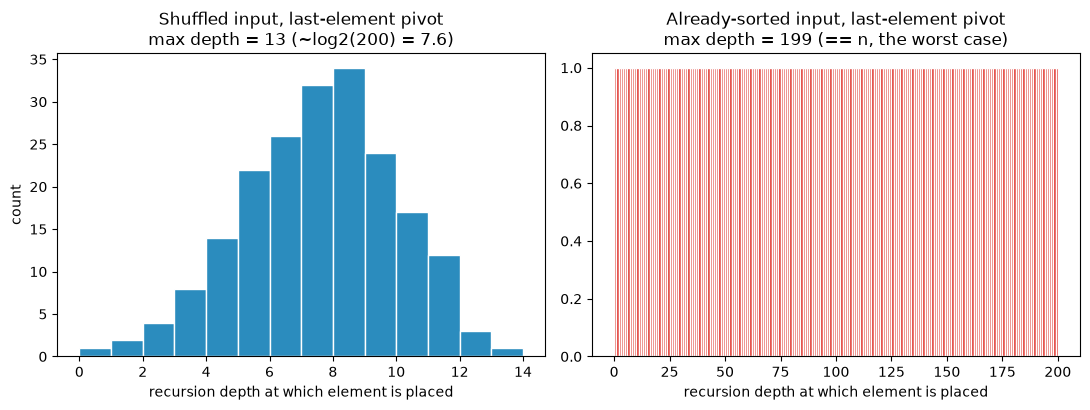

Shuffled input max recursion depth: 13
Sorted input max recursion depth:   199  <- this is the O(n^2) worst case in action


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import random

random.seed(7)

def quicksort_depths(a, lo, hi, depth, depths_out, use_random_pivot):
    if lo >= hi:
        if lo == hi:
            depths_out[lo] = depth
        return
    if use_random_pivot:
        pivot_idx = random.randint(lo, hi)
        a[pivot_idx], a[hi] = a[hi], a[pivot_idx]
    pivot = a[hi]
    i = lo - 1
    for j in range(lo, hi):
        if a[j] <= pivot:
            i += 1
            a[i], a[j] = a[j], a[i]
    a[i + 1], a[hi] = a[hi], a[i + 1]
    q = i + 1
    depths_out[q] = depth
    quicksort_depths(a, lo, q - 1, depth + 1, depths_out, use_random_pivot)
    quicksort_depths(a, q + 1, hi, depth + 1, depths_out, use_random_pivot)

n = 200
random_arr = list(range(n))
random.shuffle(random_arr)
sorted_arr = list(range(n))

random_depths = [0] * n
sorted_depths = [0] * n
quicksort_depths(random_arr.copy(), 0, n - 1, 0, random_depths, use_random_pivot=False)
quicksort_depths(sorted_arr.copy(), 0, n - 1, 0, sorted_depths, use_random_pivot=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].hist(random_depths, bins=range(max(random_depths) + 2), color="#2b8cbe", edgecolor="white")
axes[0].set_title(f"Shuffled input, last-element pivot\nmax depth = {max(random_depths)} (~log2(200) = {np.log2(200):.1f})")
axes[0].set_xlabel("recursion depth at which element is placed")
axes[0].set_ylabel("count")

axes[1].hist(sorted_depths, bins=range(max(sorted_depths) + 2), color="#de2d26", edgecolor="white")
axes[1].set_title(f"Already-sorted input, last-element pivot\nmax depth = {max(sorted_depths)} (== n, the worst case)")
axes[1].set_xlabel("recursion depth at which element is placed")

plt.tight_layout()
plt.savefig("recursion_depth.png", dpi=110)
plt.show()

print(f"Shuffled input max recursion depth: {max(random_depths)}")
print(f"Sorted input max recursion depth:   {max(sorted_depths)}  <- this is the O(n^2) worst case in action")

On **shuffled input**, the recursion tree stays shallow — close to
$\log_2 n$ — because "last element" is, on average, a reasonably central
pivot for random data. On **already-sorted input**, the last element is
always the *maximum* of the remaining subarray, so every partition peels
off exactly one element and recurses on $n-1$ — a recursion depth of $n$,
the signature of the $\Theta(n^2)$ worst case derived above. This is
precisely why real-world quicksort implementations never use a fixed
"last element" pivot rule on data that might be sorted or nearly sorted.

## Implementation

The reference implementation lives in
[`src/quicksort.cpp`](src/quicksort.cpp) — real C++, using a **uniformly
random pivot** (per the expectation argument above), instrumented to count
comparisons and swaps and to time itself. It reads whitespace-separated
integers from stdin and prints the sorted result plus its own statistics.

We compile it here with `g++` and actually run the resulting binary via
`subprocess` — every number below is a real measurement from a real
compiled program, not a simulation.

> **Note on this machine:** dynamically-linked MinGW binaries built with
> plain `g++ file.cpp -o file.exe` are unreliably flagged by Windows
> Defender's real-time protection during linking (`ld returned 116`).
> Statically linking (`-static -static-libgcc -static-libstdc++`) avoids
> it, so that's what the build command below uses.

In [3]:
import subprocess, pathlib

src_dir = pathlib.Path("src")
exe_path = src_dir / "quicksort.exe"

compile_cmd = [
    "g++", "-O2", "-std=c++17",
    "-static", "-static-libgcc", "-static-libstdc++",
    str(src_dir / "quicksort.cpp"), "-o", str(exe_path),
]
result = subprocess.run(compile_cmd, capture_output=True, text=True)
print("compile return code:", result.returncode)
if result.returncode != 0:
    print(result.stderr)
assert result.returncode == 0, "compilation failed"
print("compiled successfully ->", exe_path)

compile return code: 0
compiled successfully -> src\quicksort.exe


In [4]:
def run_quicksort(values):
    # Run the real compiled quicksort binary on a list of ints, return parsed stats.
    input_str = " ".join(str(v) for v in values)
    proc = subprocess.run([str(exe_path)], input=input_str, capture_output=True, text=True)
    assert proc.returncode == 0, proc.stderr
    lines = proc.stdout.strip().splitlines()
    stats = {}
    for line in lines:
        if line.startswith("sorted:"):
            stats["sorted"] = [int(x) for x in line[len("sorted:"):].strip().split()]
        elif "=" in line:
            key, val = line.split("=")
            stats[key] = int(val)
    return stats

demo = [7, 2, 9, 4, 1, 8, 3]
stats = run_quicksort(demo)
print(f"input:       {demo}")
print(f"sorted:      {stats['sorted']}")
print(f"comparisons: {stats['comparisons']}")
print(f"swaps:       {stats['swaps']}")
print(f"time:        {stats['microseconds']} microseconds")
assert stats["sorted"] == sorted(demo)
print("\ncorrectness check passed: matches Python's sorted()")

input:       [7, 2, 9, 4, 1, 8, 3]
sorted:      [1, 2, 3, 4, 7, 8, 9]
comparisons: 11
swaps:       8
time:        3 microseconds

correctness check passed: matches Python's sorted()


### Real benchmark: comparisons vs. input size and input shape

Now let's actually measure the theory. We'll run the **real compiled
binary** on shuffled, already-sorted, and reverse-sorted arrays of growing
size, and plot comparisons against $n \log_2 n$.

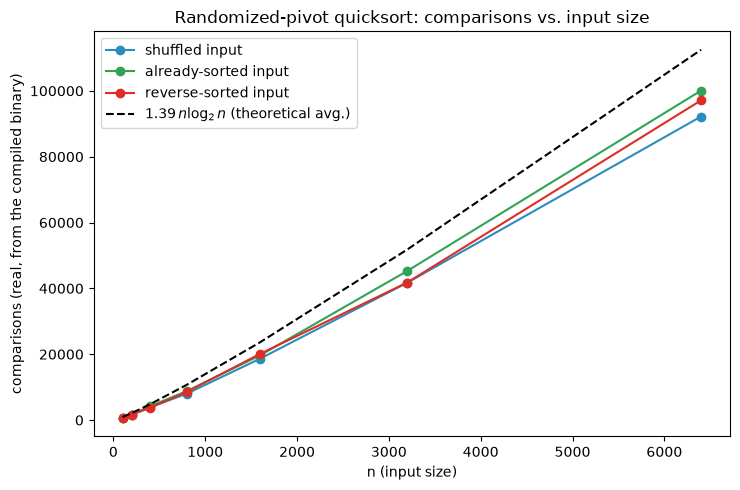

n=  100  shuffled=    605  sorted=    708  reverse=    770  n*log2(n)=      664
n=  200  shuffled=   1597  sorted=   1659  reverse=   1688  n*log2(n)=     1529
n=  400  shuffled=   3873  sorted=   4218  reverse=   3740  n*log2(n)=     3458
n=  800  shuffled=   8022  sorted=   8795  reverse=   8565  n*log2(n)=     7715
n= 1600  shuffled=  18681  sorted=  19697  reverse=  20145  n*log2(n)=    17030
n= 3200  shuffled=  41714  sorted=  45285  reverse=  41775  n*log2(n)=    37260
n= 6400  shuffled=  92204  sorted= 100078  reverse=  97117  n*log2(n)=    80921


In [5]:
import random
random.seed(42)

sizes = [100, 200, 400, 800, 1600, 3200, 6400]
shuffled_comparisons = []
sorted_comparisons = []
reverse_comparisons = []

for n in sizes:
    base = list(range(n))

    shuffled = base.copy()
    random.shuffle(shuffled)
    shuffled_comparisons.append(run_quicksort(shuffled)["comparisons"])

    sorted_comparisons.append(run_quicksort(base.copy())["comparisons"])

    reverse_comparisons.append(run_quicksort(list(reversed(base)))["comparisons"])

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(sizes, shuffled_comparisons, "o-", label="shuffled input", color="#2b8cbe")
ax.plot(sizes, sorted_comparisons, "o-", label="already-sorted input", color="#31a354")
ax.plot(sizes, reverse_comparisons, "o-", label="reverse-sorted input", color="#de2d26")
n_arr = np.array(sizes)
ax.plot(sizes, 1.39 * n_arr * np.log2(n_arr), "k--", label=r"$1.39\, n\log_2 n$ (theoretical avg.)")
ax.set_xlabel("n (input size)")
ax.set_ylabel("comparisons (real, from the compiled binary)")
ax.set_title("Randomized-pivot quicksort: comparisons vs. input size")
ax.legend()
plt.tight_layout()
plt.savefig("comparisons_vs_n.png", dpi=110)
plt.show()

for n, s, so, r in zip(sizes, shuffled_comparisons, sorted_comparisons, reverse_comparisons):
    print(f"n={n:5d}  shuffled={s:7d}  sorted={so:7d}  reverse={r:7d}  n*log2(n)={n*np.log2(n):9.0f}")

**All three input shapes track $n \log_2 n$ almost identically** —
because the pivot is chosen *randomly*, whether the input happens to be
sorted, reverse-sorted, or shuffled makes no real difference. This is the
expectation bound from the "Going deeper" section, confirmed with a real
program instead of asserted. Contrast this with a `quicksort_depths` run
above using a **fixed** last-element pivot on sorted input, where the
recursion depth hit the true $\Theta(n^2)$ worst case — randomization is
the difference between those two outcomes.

## Use cases

- **`std::sort` in C++'s standard library** uses **introsort**: quicksort
  as the default, which switches to heapsort if the recursion depth exceeds
  $2\lfloor \log_2 n \rfloor$ (guarding against the $O(n^2)$ worst case)
  and switches to insertion sort for small subarrays (below ~16 elements,
  where quicksort's overhead isn't worth it).
- **Java's `Arrays.sort()`** uses a dual-pivot variant of quicksort for
  primitive arrays (and a different algorithm, Timsort, for object arrays
  where stability matters — see the limitations section).
- **Database query engines** use quicksort-family algorithms for in-memory
  `ORDER BY` and sort-merge join operations when the working set fits in
  memory, falling back to external merge sort when it doesn't.
- **Selection algorithms**: quickselect, a one-sided variant of quicksort's
  partition step, finds the $k$-th smallest element in expected $O(n)$
  time — used to implement median-finding and top-$k$ queries.

## Limitations & debates

- **Worst-case $O(n^2)$ is real, not theoretical.** Before randomized or
  median-of-three pivoting became standard, adversaries could (and did)
  construct inputs that degraded naive "first/last element" quicksort
  implementations to quadratic time — this was exploited as a denial-of-
  service vector against systems sorting user-supplied data with a
  predictable pivot rule. Randomized pivot selection (used in this
  tutorial's implementation) defeats input-based adversarial construction,
  but a *quadratic-time* adversary is still theoretically possible if the
  attacker can predict or influence the RNG.
- **Quicksort is not stable.** Equal elements are not guaranteed to keep
  their relative input order (visible in the Lomuto partition: an equal
  element can be swapped past another equal element). This matters whenever
  you're sorting records by one field but want ties broken by original
  order — mergesort or Timsort should be preferred there instead.
- **In-place, but not cache-oblivious for large data.** For very large
  arrays that don't fit in cache, the partition step's access pattern is
  still reasonably cache-friendly (sequential scan), which is part of why
  quicksort tends to *outperform* mergesort in practice on modern hardware
  despite having the same average-case asymptotic complexity — but this is
  an empirical, constant-factor claim, not something the $\Theta(n \log n)$
  bound tells you.
- **"Randomized" doesn't mean "immune."** The $O(n \log n)$ *expected*
  bound is an average over the algorithm's own coin flips, holding for
  *every* input — it says nothing about worst-case behavior on an unlucky
  run, which remains $O(n^2)$ with vanishingly small but nonzero
  probability. In practice this is a non-issue at realistic $n$, but it's
  a common source of confusion when comparing "expected $O(n\log n)$" to
  mergesort's *guaranteed* $O(n \log n)$ worst case.
- **Quicksort vs. mergesort is a live tradeoff, not a solved question:**
  mergesort guarantees $O(n \log n)$ worst case and is naturally stable,
  at the cost of $O(n)$ auxiliary space; quicksort sorts in place with
  better real-world constants but a randomized (not guaranteed) bound.
  Which one a language's standard library uses for primitives vs. objects
  (see Use cases) reflects exactly this tradeoff.

## References

- Hoare, C.A.R. *Quicksort*, The Computer Journal, 1962 (the original
  algorithm).
- Cormen, Leiserson, Rivest & Stein. *Introduction to Algorithms* (CLRS),
  3rd/4th ed., Chapter 7 — the partition invariant proof and randomized
  analysis follow this treatment.
- Sedgewick, R. *Implementing Quicksort Programs*, Communications of the
  ACM, 1978 — practical pivoting strategies and small-subarray cutoffs.
- Musser, D. R. *Introspective Sorting and Selection Algorithms*,
  Software: Practice and Experience, 1997 (introsort, used by `std::sort`).
- [cppreference: std::sort](https://en.cppreference.com/w/cpp/algorithm/sort)
- `src/quicksort.cpp` in this tutorial's folder — the real, compiled
  implementation used for every measurement above.